## Roadmap
- [x] 1 · Setup + explore
- [x] 2 · Baseline submission (~0.50, on the board)
- [ ] 3 · Mine labels from reports  
- [ ] 4 · Train image model
- [ ] 5 · Make it efficient
- [ ] 6 · Final submission

STUDY: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149

[1] LABELS
    ACL               : 0
    MCL               : 0
    Medial Meniscus   : 0
    Lateral Meniscus  : 0
    Medial OA         : 0
    Lateral OA        : 0
    PF OA             : 1   <-- YES
    Effusion          : 1   <-- YES
    Synovitis         : 0
    Baker's           : 0
    Contusion         : 0
    Fracture          : 0
    → positive: ['PF OA', 'Effusion']

[2] REPORT (first 400 chars, may be non-English)
    Antecedentes Clínicos: Esguince rodilla. [DATE]. Hallazgos: No hay alteraciones de señal significativas de la médula ósea. Ligamentos cruzados y colaterales dentro de límites normales. Amputación marginal del cuerpo del menisco lateral. Menisco medial de morfología y señal conservada, sin signos de rotura. Cartílagos de los compartimentos femorotibiales sin alteraciones. Fina úlcera condral focal 

[3] SERIES BREAKDOWN
    5 series total
      plane  fluid_sens  fat_supp  slices img_size

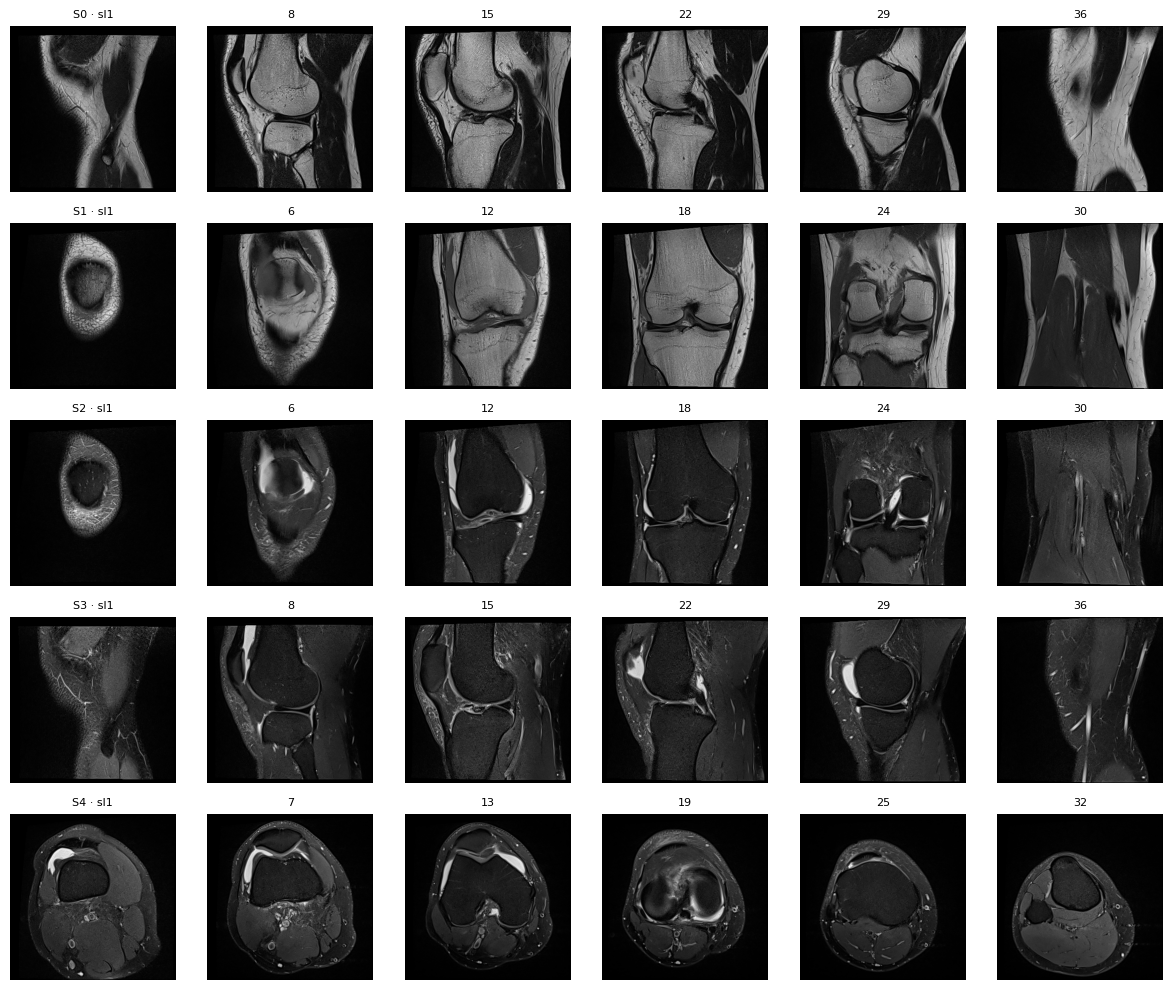

In [1]:
import glob, os, pydicom
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

COMP = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train   = pd.read_csv(f"{COMP}/train.csv")
tseries = pd.read_csv(f"{COMP}/train_series.csv")
label_cols = [c for c in train.columns if c not in ("StudyInstanceUID", "Report")]

# pick one LABELED study (so labels aren't NaN)
uid = train.dropna(subset=label_cols).iloc[0]["StudyInstanceUID"]
row = train[train.StudyInstanceUID == uid].iloc[0]

print("="*64); print("STUDY:", uid); print("="*64)

# [1] labels
print("\n[1] LABELS")
for c in label_cols:
    print(f"    {c:18s}: {int(row[c])}" + ("   <-- YES" if int(row[c]) else ""))
pos = [c for c in label_cols if int(row[c]) == 1]
print("    → positive:", pos if pos else "none (healthy knee)")

# [2] report
print("\n[2] REPORT (first 400 chars, may be non-English)")
print("   ", str(row.get("Report","")).replace("\n"," ")[:400] or "(none)")

# [3] series table
print("\n[3] SERIES BREAKDOWN")
meta = tseries[tseries.StudyInstanceUID == uid].set_index("SeriesInstanceUID")
series_dirs = sorted(glob.glob(f"{COMP}/train_series/{uid}/*"))
info = []
for sd in series_dirs:
    sid  = os.path.basename(sd)
    dcms = glob.glob(f"{sd}/*.dcm")
    d    = pydicom.dcmread(dcms[0]); arr = d.pixel_array
    m    = meta.loc[sid] if sid in meta.index else {}
    info.append({
        "plane":      m.get("Anatomical_Plane","?") if len(m) else "?",
        "fluid_sens": m.get("Fluid_Sensitive","?")  if len(m) else "?",
        "fat_supp":   m.get("Fat_Suppression","?")  if len(m) else "?",
        "slices":     len(dcms),
        "img_size":   f"{d.Rows}x{d.Columns}",
        "pix_range":  f"{int(arr.min())}–{int(arr.max())}",
    })
print(f"    {len(series_dirs)} series total")
print(pd.DataFrame(info).to_string(index=True))

# [4] preview: 6 evenly-spaced slices per series
print("\n[4] PREVIEW")
n = 6
fig, axes = plt.subplots(len(series_dirs), n, figsize=(n*2, len(series_dirs)*2))
axes = np.atleast_2d(axes)
for ri, sd in enumerate(series_dirs):
    sl = [pydicom.dcmread(f) for f in sorted(glob.glob(f"{sd}/*.dcm"))]
    sl.sort(key=lambda s: int(getattr(s, "InstanceNumber", 0)))
    for ci, k in enumerate(np.linspace(0, len(sl)-1, n).astype(int)):
        ax = axes[ri, ci]; ax.imshow(sl[k].pixel_array, cmap="gray"); ax.axis("off")
        ax.set_title(f"S{ri} · sl{k+1}" if ci == 0 else str(k+1), fontsize=8)
plt.tight_layout(); plt.show()

In [2]:
import pandas as pd
COMP = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
train = pd.read_csv(f"{COMP}/train.csv")
label_cols = [c for c in train.columns if c not in ("StudyInstanceUID", "Report")]

labeled = train.dropna(subset=label_cols)
print(f"{len(labeled)} labeled / {len(train)} total studies "
      f"({100*len(labeled)/len(train):.0f}% labeled)")

# how common is each finding among labeled studies?
print("\npositive rate per finding:")
print((labeled[label_cols].mean().sort_values(ascending=False)*100).round(1).astype(str) + "%")



58 labeled / 4407 total studies (1% labeled)

positive rate per finding:
Effusion            60.3%
Synovitis           46.6%
Medial Meniscus     44.8%
ACL                 41.4%
Lateral Meniscus    39.7%
PF OA               36.2%
Contusion           32.8%
Fracture            31.0%
Medial OA           25.9%
Baker's             20.7%
Lateral OA          19.0%
MCL                 15.5%
dtype: object


# We are shift focus to the reports

## One-line reason
Only **58 / 4,407 studies (~1%)** have the 12 labels filled in — too few to train an image model. But **all 4,407 have a written report**. We read those to turn 58 usable studies into ~4,400.

## The problem
A deep learning model needs **thousands** of labeled examples. We have 58. Training on 58 would just memorize them and learn nothing general.

| | Count |
|---|---|
| Studies with labels | 58 |
| Studies with a report but no labels | ~4,349 |
| Total studies | 4,407 |

## The insight
The ~4,349 "unlabeled" studies aren't really unlabeled — the answers sit inside the reports as free text.
Example: *"rotura de menisco interno"* = medial meniscus tear. The diagnosis is there; it just isn't a 0/1 column yet.
So we don't collect new labels — we **extract** labels we already have.

## The plan
1. Read the reports → pull out the 12 yes/no answers.
2. This gives ~4,349 newly labeled studies.
3. Train the image model on those.
4. Keep the 58 human-verified labels as a **validation set** (our trusted ruler).

In [3]:
reports = train.dropna(subset=["Report"])
print(len(reports), "studies have a report\n")
for i in range(3):
    r = reports.iloc[i]["Report"]
    print("="*50)
    print(str(r)[:500])

4407 studies have a report

Técnica: RMN de la rodilla. Resultados: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame. . Impresión: Rotura de menisco interno. Signo de necrosis avascular subcondral en el cóndilo femoral medial. Artrosis femorotibial medial. Derrame.
[DATE]: * MR Knie Rechts 15ch AA Klinische Inlichtingen: [DATE]. Diagnostische vraagstellling: Meniscusscheur/mediaal? Scanprotocol (DRB) : sag intermediair gewogen seq zonder en met fs, ax/ cor pd gewogen seq fs, cor T1 gewogen seq Bevindingen:
Hallazgos:
No hay alteraciones en significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Aumento de señal del cuerno posterior del menisco medial que no impresiona contactar con la
superficie articular, sin caracteres propios de rotura.
Menisco lateral de morfología y señal conservada, sin signos de rotura.
Úlceras condrales de espesor parcial con fenómenos co

## Two ways to pull the 12 answers out of the foreign-language reports

### Option A — translate, then search
Translate each report to English, then look for keywords ("ACL tear", "effusion").
- ✅ Simple
- ❌ Medical terms get mangled in translation

### Option B — let a language model read it
Hand the raw report (any language) to a model and ask "which of these 12 findings are mentioned?" It reads Spanish, Dutch, etc. natively.
- ✅ More accurate
- ❌ Slightly more setup

**Why it matters:** whatever we pick becomes the factory that stamps ~4,300 training labels. Get it right → the image model learns from good data. Get it sloppy → it learns from noise.

**Note:** label-mining runs in a *separate* notebook with internet ON. It's prep, not part of your submission — no offline constraint here.